In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('Cardiotocographic.csv')
data.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [4]:
data.shape

(2126, 14)

In [5]:
data.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


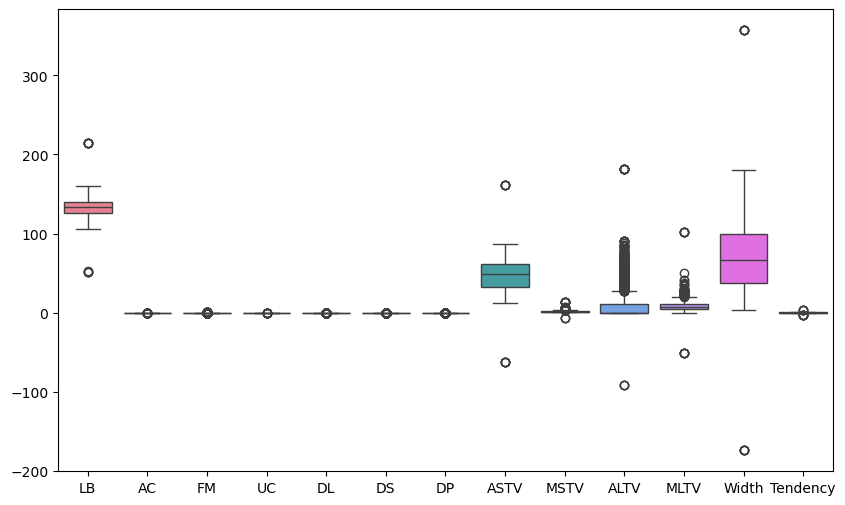

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data.drop('NSP',axis=1))
plt.show()

#### 1.	Data Cleaning and Preparation:

In [7]:
data.isna().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [18]:
# Calculate medians for each numeric column first (optional but clearer)
lb_median = data['LB'].median()
ac_median = data['AC'].median()
fm_median = data['FM'].median()
uc_median = data['UC'].median()
dl_median = data['DL'].median()
ds_median = data['DS'].median()
dp_median = data['DP'].median()
astv_median = data['ASTV'].median()
mstv_median = data['MSTV'].median()
altv_median = data['ALTV'].median()
mltv_median = data['MLTV'].median()
width_median = data['Width'].median()
tendency_median = data['Tendency'].median()
nsp_median = data['NSP'].median()   # fixed: was 'NSP ' (with space)

# Fill missing values using dictionary mapping
data.fillna(
    {
        'LB': lb_median,
        'AC': ac_median,
        'FM': fm_median,
        'UC': uc_median,
        'DL': dl_median,
        'DS': ds_median,
        'DP': dp_median,
        'ASTV': astv_median,
        'MSTV': mstv_median,
        'ALTV': altv_median,
        'MLTV': mltv_median,
        'Width': width_median,
        'Tendency': tendency_median,
        'NSP': nsp_median
    },
    inplace=True
)



In [19]:
data.isna().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [27]:
data.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

###### Hence dtype is already in float there is no neede for convertion

Outlier detection report:

LB: 10 outliers
AC: 43 outliers
FM: 347 outliers
UC: 13 outliers
DL: 125 outliers
DS: 120 outliers
DP: 284 outliers
ASTV: 10 outliers
MSTV: 80 outliers
ALTV: 318 outliers
MLTV: 81 outliers
Width: 10 outliers
Tendency: 10 outliers
NSP: 559 outliers

 Boxplot visualization for each numeric column:



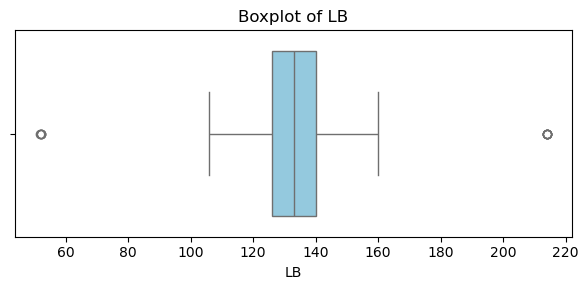

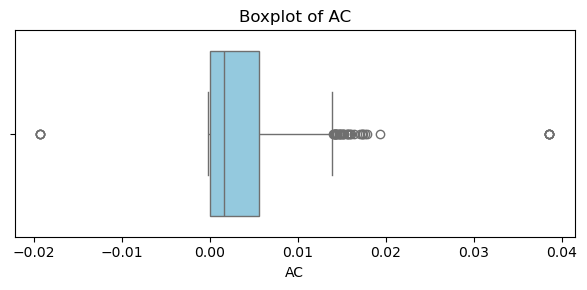

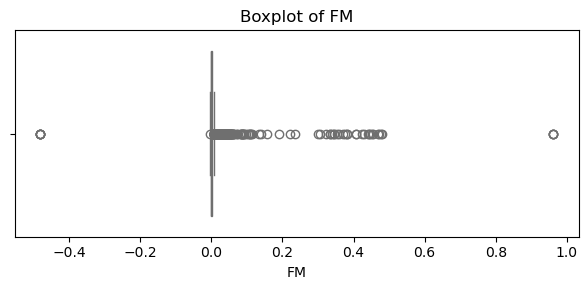

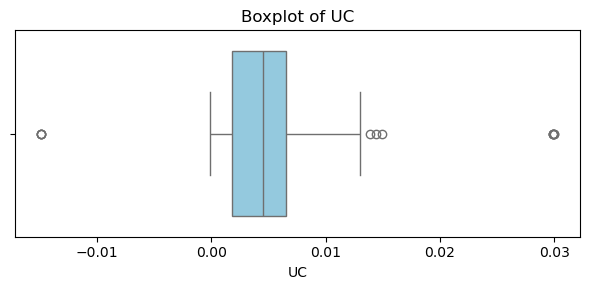

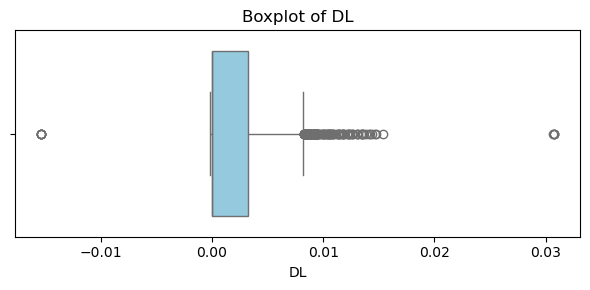

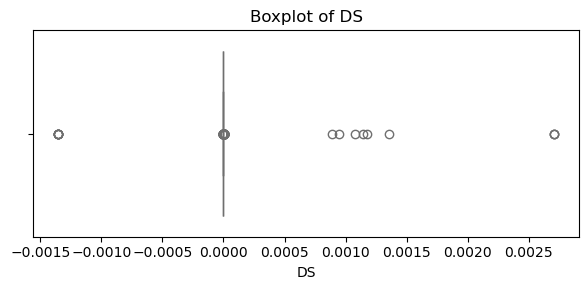

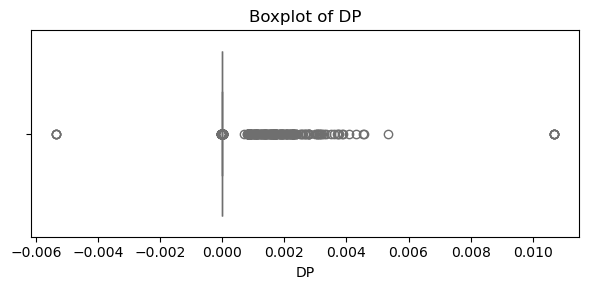

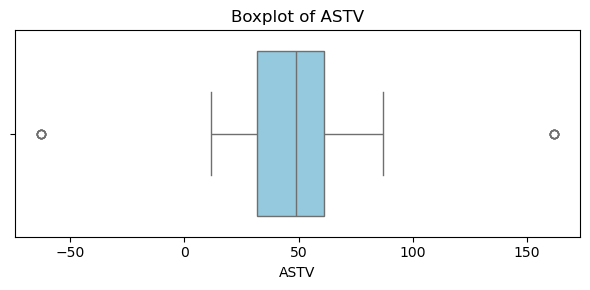

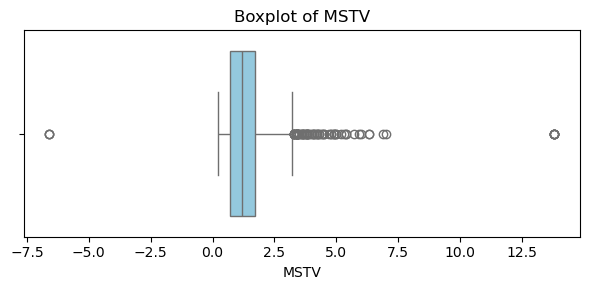

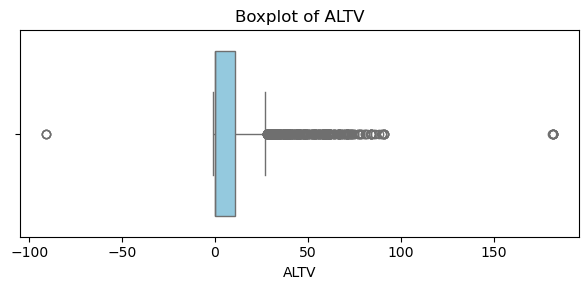

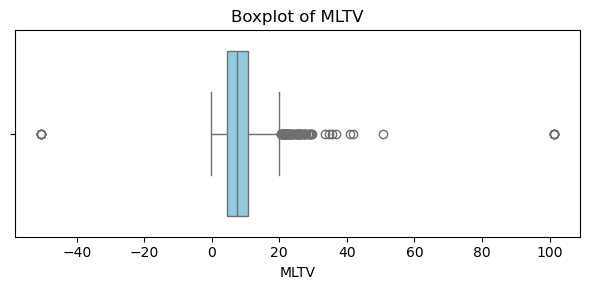

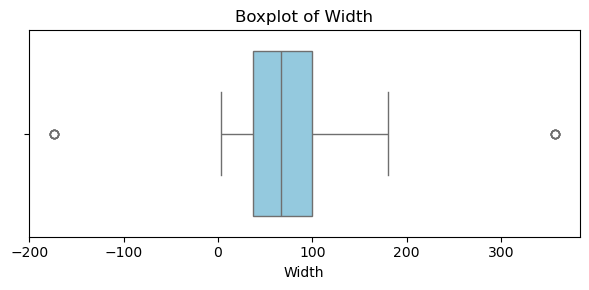

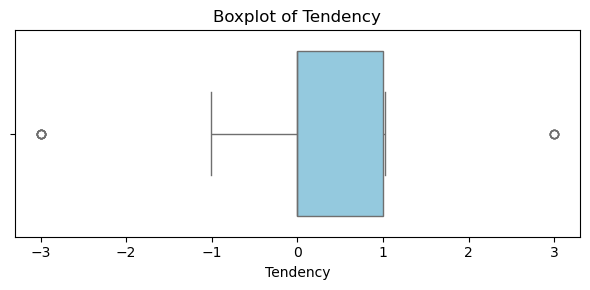

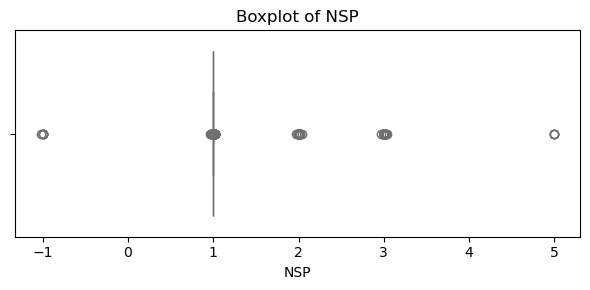


Outlier treatment completed for all numeric columns.

Boxplots after outlier treatment:



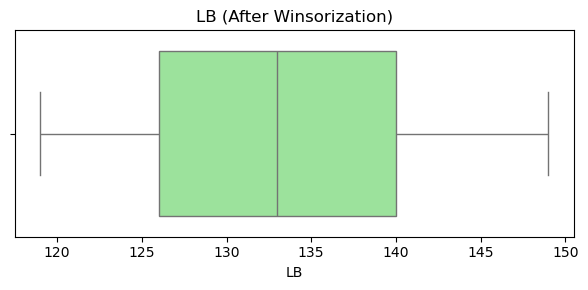

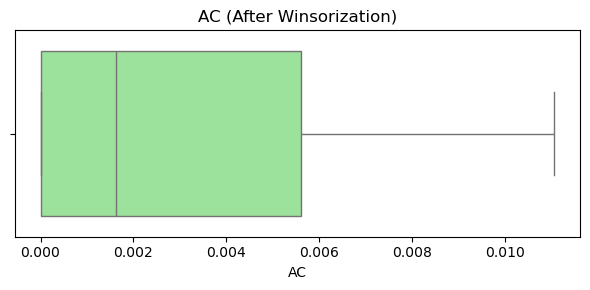

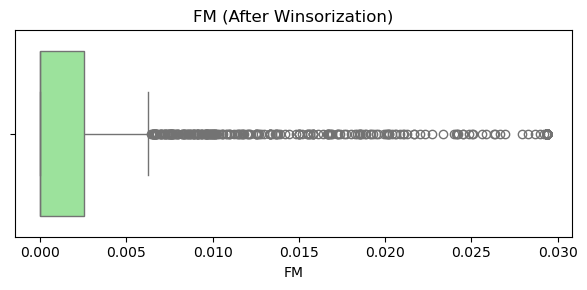

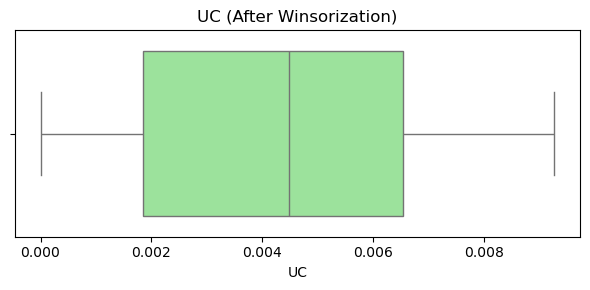

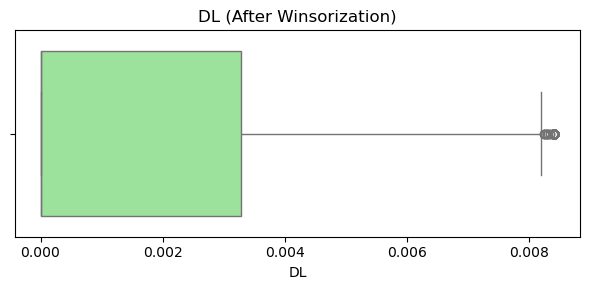

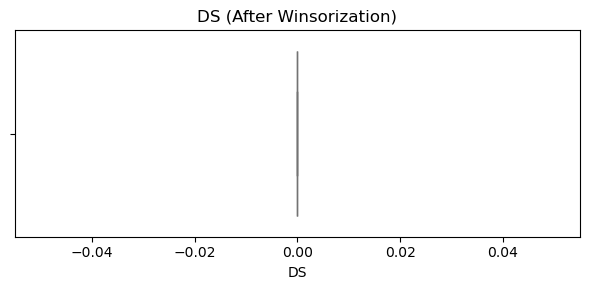

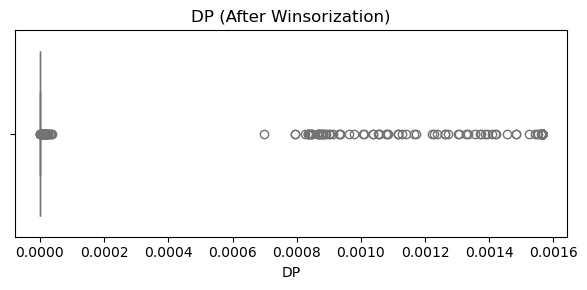

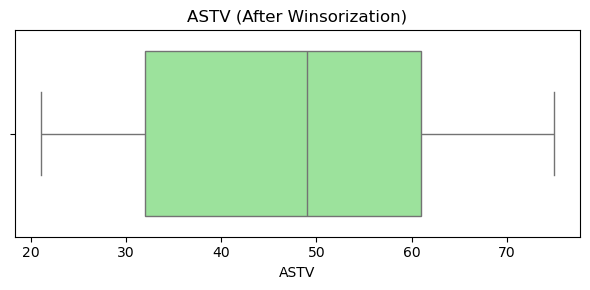

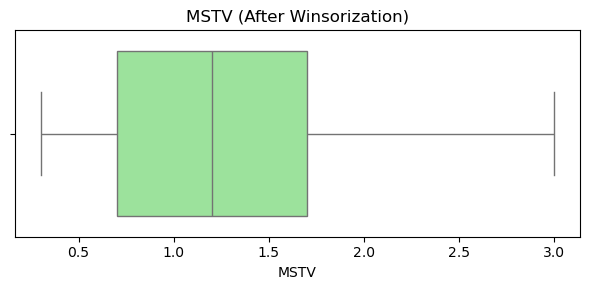

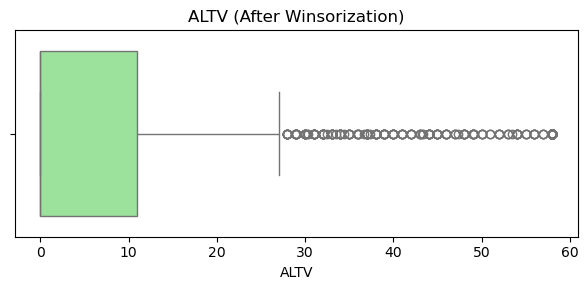

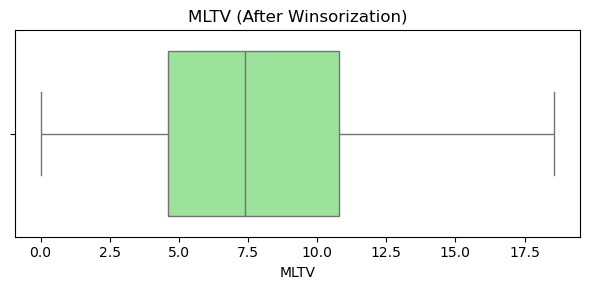

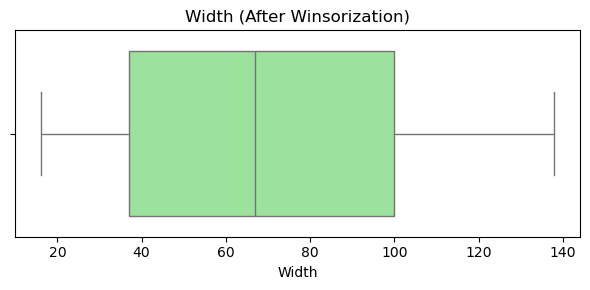

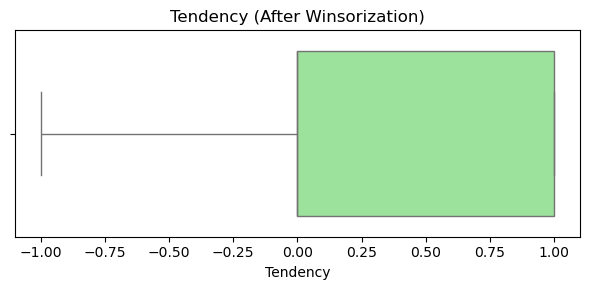

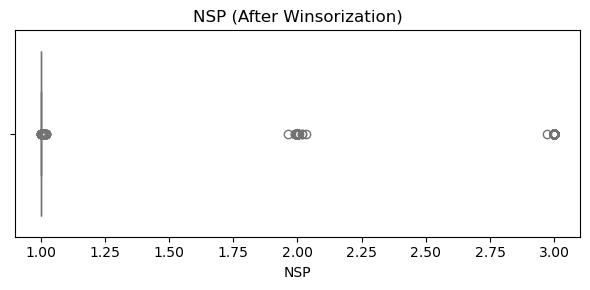

In [28]:
# Select only numeric columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns


# Step 1: Detect outliers (IQR method)

print("Outlier detection report:\n")
outlier_counts = {}

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]
    outlier_counts[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers")


# Step 2: Simple visual check for each column

print("\n Boxplot visualization for each numeric column:\n")

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


# Step 3: Handle outliers (Winsorization)
# Clip values outside 5th–95th percentile

for col in numeric_cols:
    lower = data[col].quantile(0.05)
    upper = data[col].quantile(0.95)
    data[col] = np.clip(data[col], lower, upper)

print("\nOutlier treatment completed for all numeric columns.\n")


# Step 4: Visualize again after winsorization

print("Boxplots after outlier treatment:\n")

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data[col], color="lightgreen")
    plt.title(f"{col} (After Winsorization)")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


#### 2.	Statistical Summary:

In [31]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,2126.0,133.371211,8.882701,119.0,126.000000,133.000000,140.000000,149.000000
AC,2126.0,0.003054,0.003560,0.0,0.000000,0.001634,0.005606,0.011059
FM,2126.0,0.003520,0.007512,0.0,0.000000,0.000000,0.002567,0.029395
UC,2126.0,0.004308,0.002844,0.0,0.001851,0.004484,0.006536,0.009277
DL,2126.0,0.001795,0.002670,0.0,0.000000,0.000000,0.003289,0.008412
DS,2126.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
DP,2126.0,0.000117,0.000392,0.0,0.000000,0.000000,0.000000,0.001564
ASTV,2126.0,46.961986,16.656321,21.0,32.000000,49.000000,61.000000,75.000000
MSTV,2126.0,1.299399,0.754105,0.3,0.700000,1.200000,1.700000,3.000000
ALTV,2126.0,9.467948,16.801511,0.0,0.000000,0.000000,11.000000,58.000000


In [34]:
summary = data.describe().T 
summary['median'] = data.median()
summary['IQR'] = data.quantile(0.75) - data.quantile(0.25)

In [35]:
summary

,count,mean,std,min,25%,50%,75%,max,median,IQR
LB,2126.0,133.371211,8.882701,119.0,126.000000,133.000000,140.000000,149.000000,133.000000,14.000000
AC,2126.0,0.003054,0.003560,0.0,0.000000,0.001634,0.005606,0.011059,0.001634,0.005606
FM,2126.0,0.003520,0.007512,0.0,0.000000,0.000000,0.002567,0.029395,0.000000,0.002567
UC,2126.0,0.004308,0.002844,0.0,0.001851,0.004484,0.006536,0.009277,0.004484,0.004685
DL,2126.0,0.001795,0.002670,0.0,0.000000,0.000000,0.003289,0.008412,0.000000,0.003289
DS,2126.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DP,2126.0,0.000117,0.000392,0.0,0.000000,0.000000,0.000000,0.001564,0.000000,0.000000
ASTV,2126.0,46.961986,16.656321,21.0,32.000000,49.000000,61.000000,75.000000,49.000000,29.000000
MSTV,2126.0,1.299399,0.754105,0.3,0.700000,1.200000,1.700000,3.000000,1.200000,1.000000
ALTV,2126.0,9.467948,16.801511,0.0,0.000000,0.000000,11.000000,58.000000,0.000000,11.000000


In [36]:
for col in data.select_dtypes(include=['float64', 'int64']).columns:
    mean = data[col].mean()
    median = data[col].median()
    std = data[col].std()

    # Detect possible skewness
    if mean > median:
        skew_type = "positively skewed (right-skewed)"
    elif mean < median:
        skew_type = "negatively skewed (left-skewed)"
    else:
        skew_type = "symmetrical"

    print(f"- {col}: Mean = {mean:.2f}, Median = {median:.2f}, Std = {std:.2f} → {skew_type}")

- LB: Mean = 133.37, Median = 133.00, Std = 8.88 → positively skewed (right-skewed)
- AC: Mean = 0.00, Median = 0.00, Std = 0.00 → positively skewed (right-skewed)
- FM: Mean = 0.00, Median = 0.00, Std = 0.01 → positively skewed (right-skewed)
- UC: Mean = 0.00, Median = 0.00, Std = 0.00 → negatively skewed (left-skewed)
- DL: Mean = 0.00, Median = 0.00, Std = 0.00 → positively skewed (right-skewed)
- DS: Mean = 0.00, Median = 0.00, Std = 0.00 → symmetrical
- DP: Mean = 0.00, Median = 0.00, Std = 0.00 → positively skewed (right-skewed)
- ASTV: Mean = 46.96, Median = 49.00, Std = 16.66 → negatively skewed (left-skewed)
- MSTV: Mean = 1.30, Median = 1.20, Std = 0.75 → positively skewed (right-skewed)
- ALTV: Mean = 9.47, Median = 0.00, Std = 16.80 → positively skewed (right-skewed)
- MLTV: Mean = 7.95, Median = 7.40, Std = 4.87 → positively skewed (right-skewed)
- Width: Mean = 70.03, Median = 67.00, Std = 37.46 → positively skewed (right-skewed)
- Tendency: Mean = 0.32, Median = 0.00, S

#### 3.	Data Visualization:

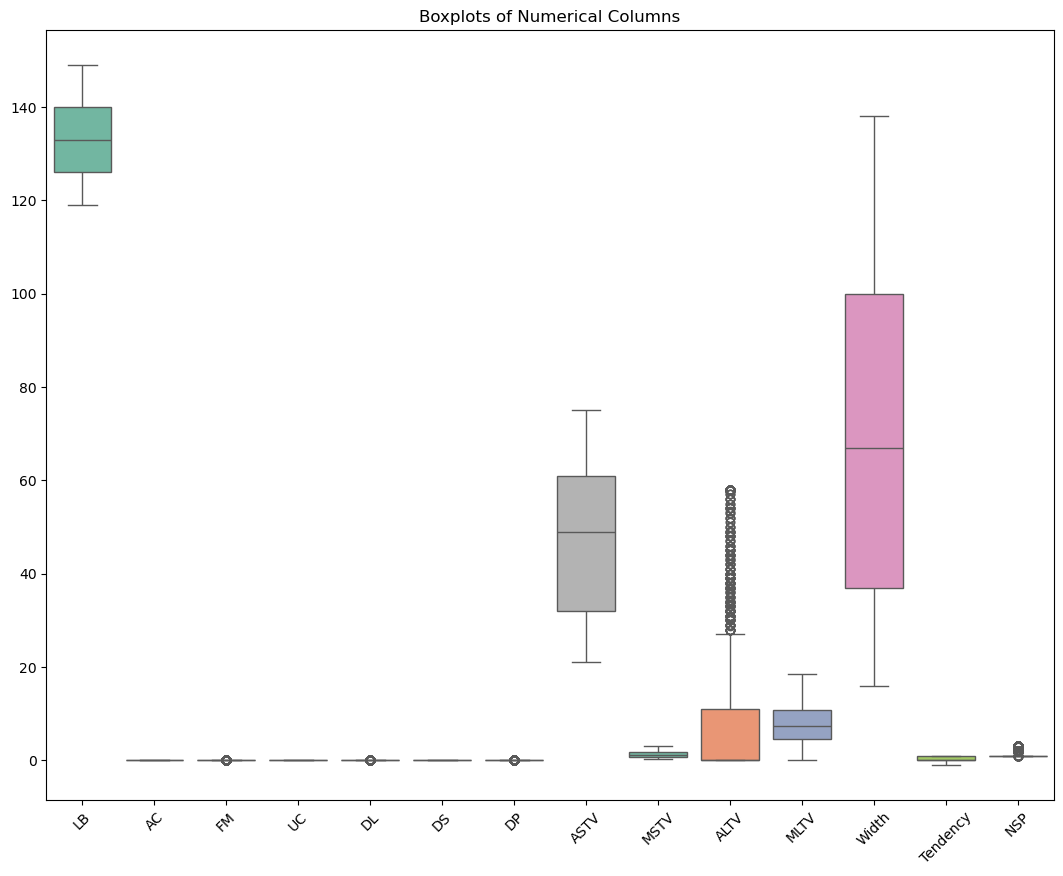

In [51]:
#  Boxplot for all numeric columns
plt.figure(figsize=(13, 10))
sns.boxplot(data=data, palette="Set2")
plt.title("Boxplots of Numerical Columns")
plt.xticks(rotation=45)
plt.show()

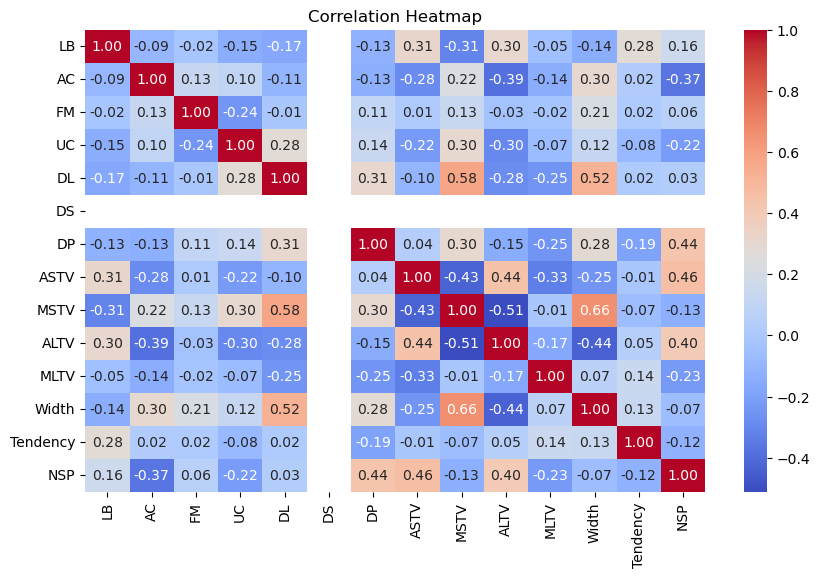

In [42]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

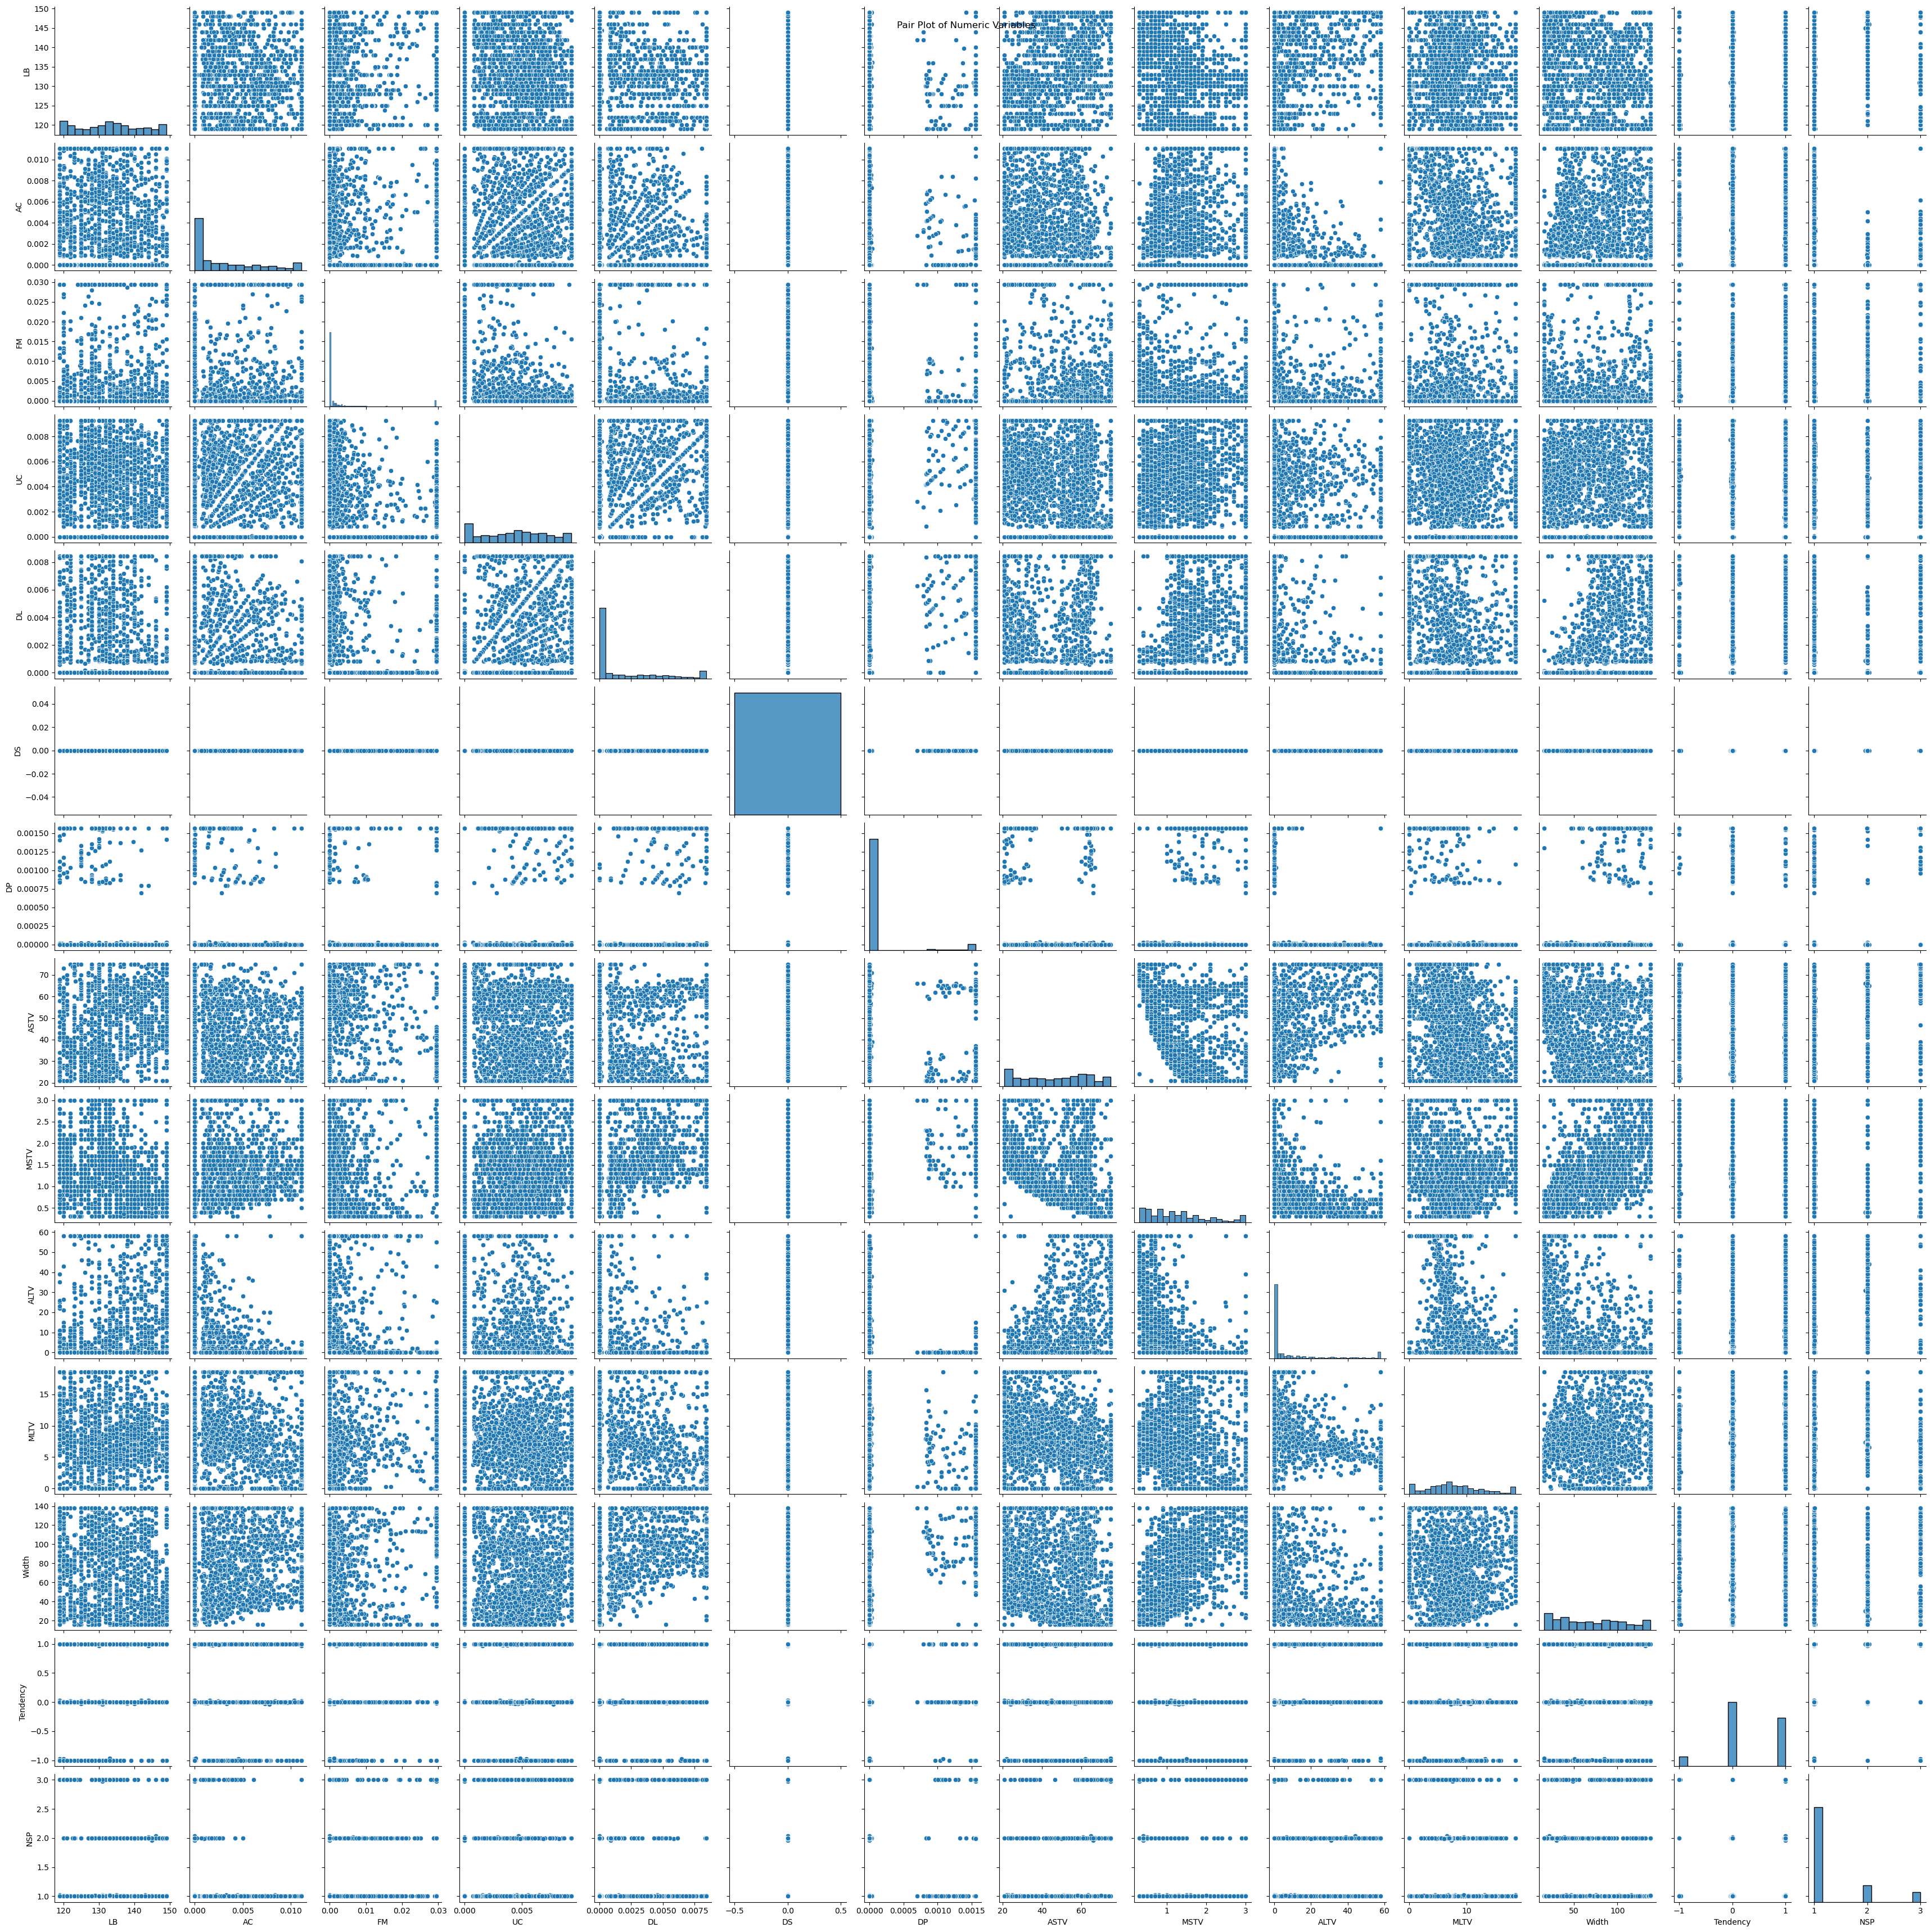

In [60]:
sns.pairplot(data[numeric_cols])
plt.suptitle("Pair Plot of Numeric Variables")
plt.show()

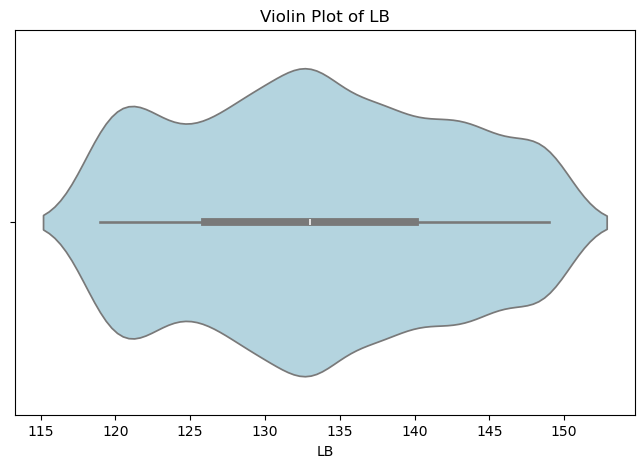

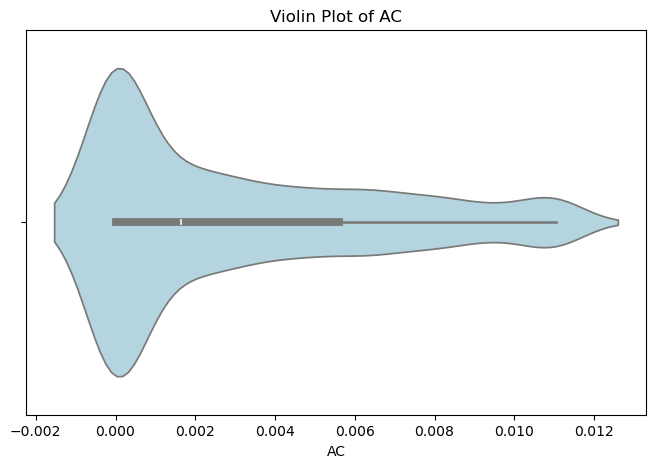

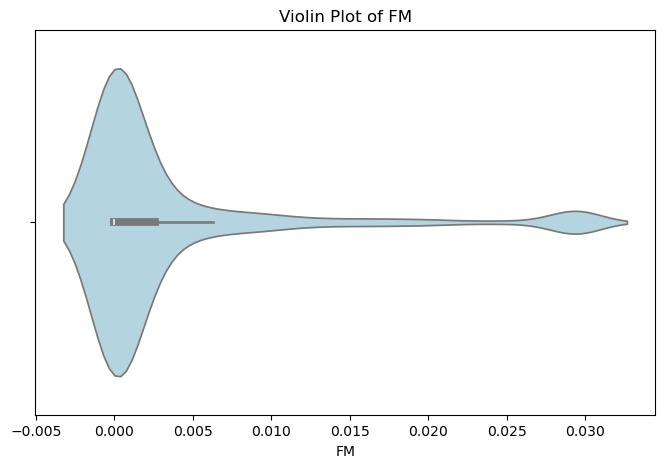

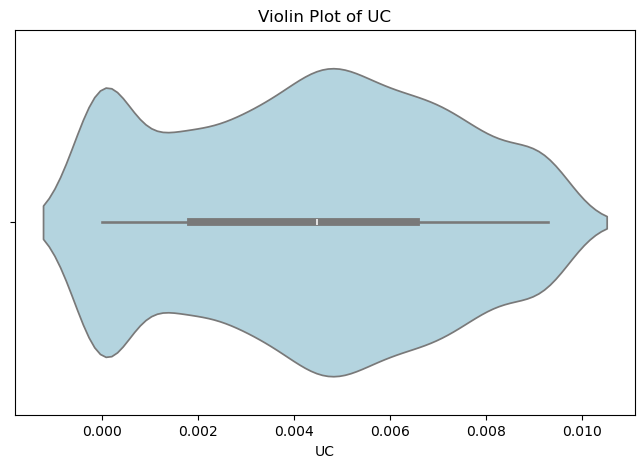

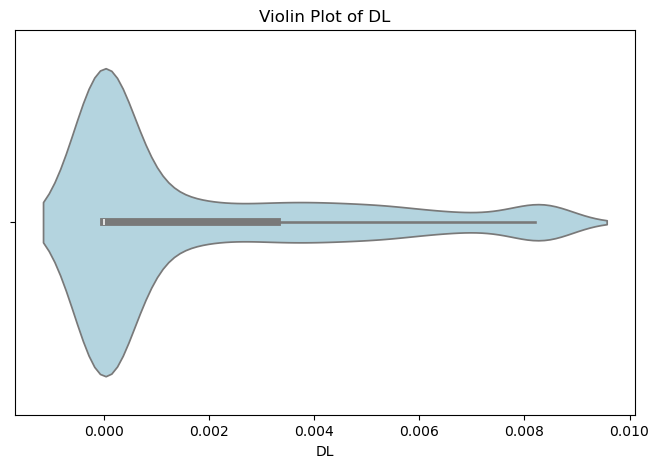

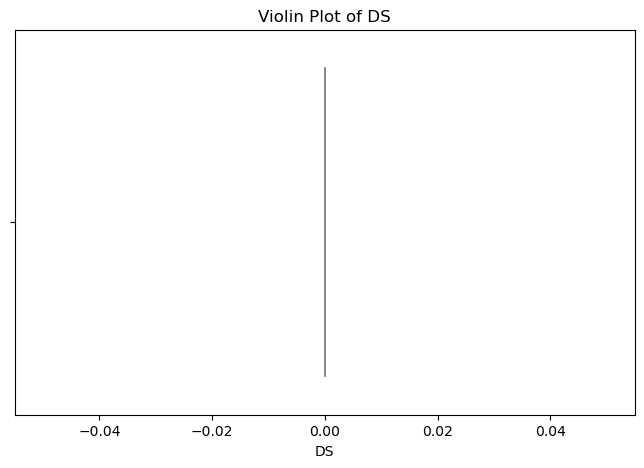

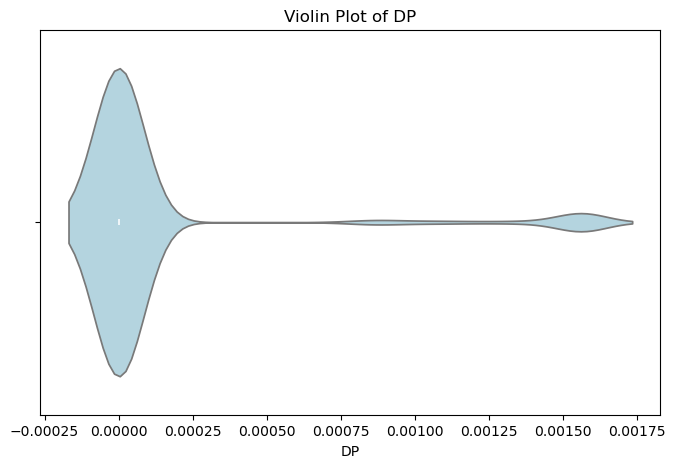

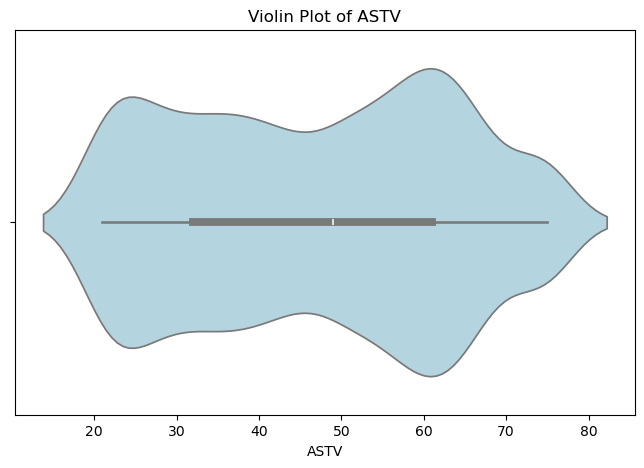

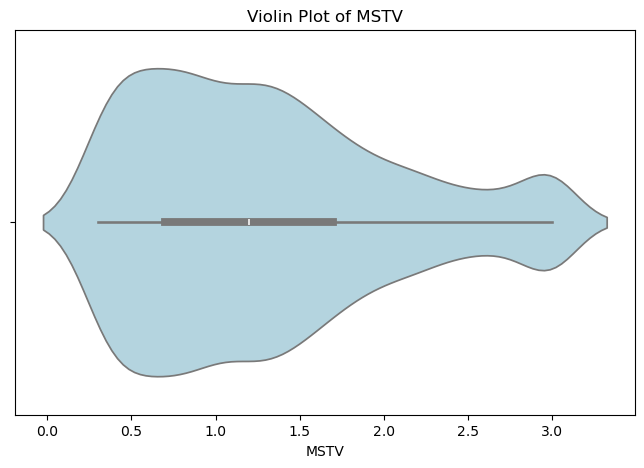

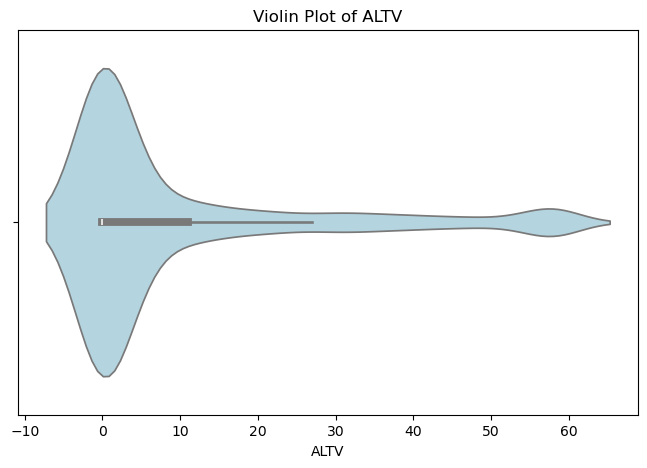

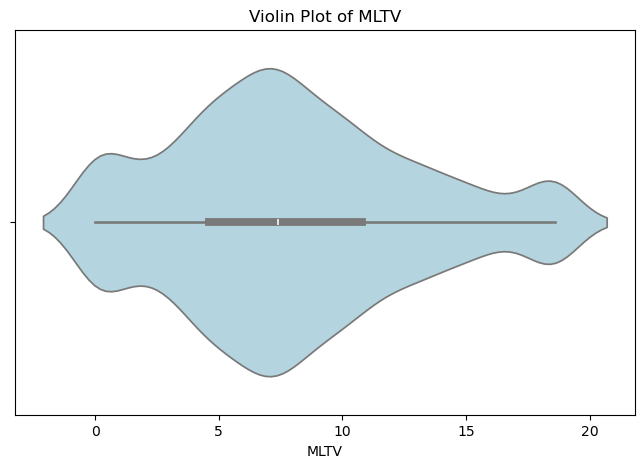

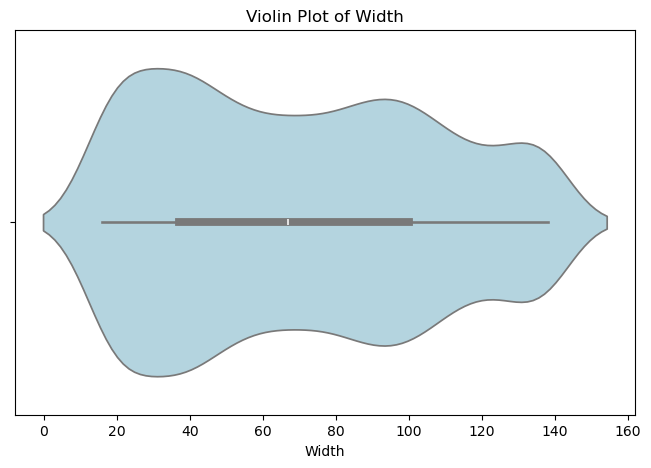

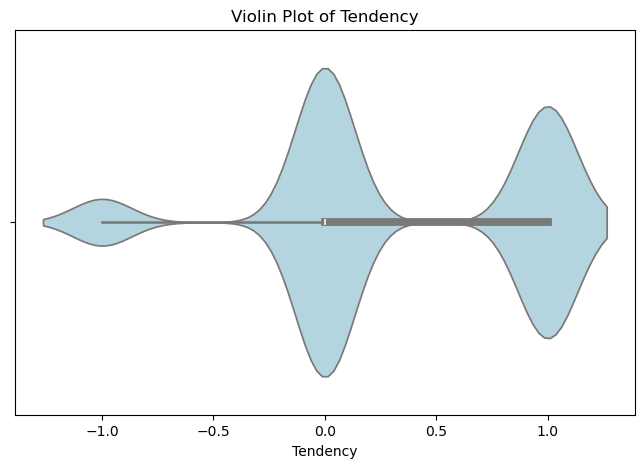

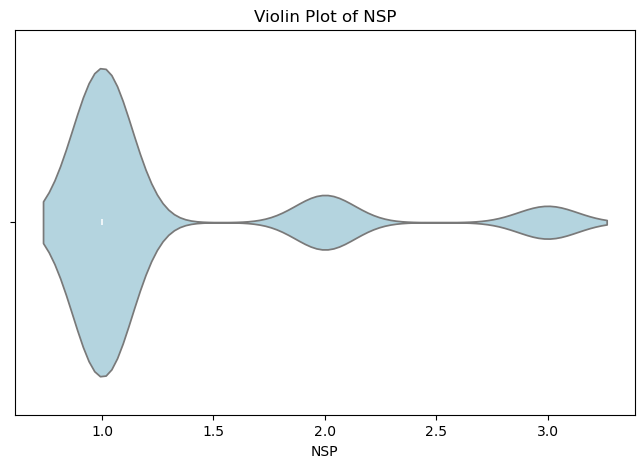

In [68]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.violinplot(x=data[col], color='lightblue')
    plt.title(f"Violin Plot of {col}")
    plt.show()

#### 4.	Pattern Recognition and Insights:

In [62]:
corr = data.corr()
corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.093672,-0.018579,-0.145094,-0.165633,NaN,-0.126532,0.312859,-0.312108,0.304389,-0.047727,-0.143671,0.275728,0.155884
AC,-0.093672,1.000000,0.125217,0.102022,-0.105252,NaN,-0.133541,-0.283467,0.222604,-0.386880,-0.143452,0.301176,0.020788,-0.368200
FM,-0.018579,0.125217,1.000000,-0.244614,-0.013618,NaN,0.105458,0.008438,0.130165,-0.033986,-0.022104,0.210951,0.018232,0.059563
UC,-0.145094,0.102022,-0.244614,1.000000,0.276167,NaN,0.136532,-0.224229,0.300726,-0.298445,-0.073058,0.121633,-0.081251,-0.220954
DL,-0.165633,-0.105252,-0.013618,0.276167,1.000000,NaN,0.306760,-0.104482,0.576028,-0.278150,-0.251451,0.523690,0.016322,0.032706
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,-0.126532,-0.133541,0.105458,0.136532,0.306760,NaN,1.000000,0.037801,0.302540,-0.146858,-0.247645,0.284633,-0.188665,0.436176
ASTV,0.312859,-0.283467,0.008438,-0.224229,-0.104482,NaN,0.037801,1.000000,-0.430979,0.440559,-0.331590,-0.246979,-0.008974,0.462909
MSTV,-0.312108,0.222604,0.130165,0.300726,0.576028,NaN,0.302540,-0.430979,1.000000,-0.511507,-0.006026,0.661009,-0.066315,-0.128378
ALTV,0.304389,-0.386880,-0.033986,-0.298445,-0.278150,NaN,-0.146858,0.440559,-0.511507,1.000000,-0.166209,-0.438368,0.047184,0.398261


In [64]:
# Find pairs of features with correlation > 0.7 or < -0.7
strong_corr = corr[(corr > 0.7) | (corr < -0.7)]
print("Strong correlations:\n", strong_corr)

Strong correlations:
            LB   AC   FM   UC   DL  DS   DP  ASTV  MSTV  ALTV  MLTV  Width  \
LB        1.0  NaN  NaN  NaN  NaN NaN  NaN   NaN   NaN   NaN   NaN    NaN   
AC        NaN  1.0  NaN  NaN  NaN NaN  NaN   NaN   NaN   NaN   NaN    NaN   
FM        NaN  NaN  1.0  NaN  NaN NaN  NaN   NaN   NaN   NaN   NaN    NaN   
UC        NaN  NaN  NaN  1.0  NaN NaN  NaN   NaN   NaN   NaN   NaN    NaN   
DL        NaN  NaN  NaN  NaN  1.0 NaN  NaN   NaN   NaN   NaN   NaN    NaN   
DS        NaN  NaN  NaN  NaN  NaN NaN  NaN   NaN   NaN   NaN   NaN    NaN   
DP        NaN  NaN  NaN  NaN  NaN NaN  1.0   NaN   NaN   NaN   NaN    NaN   
ASTV      NaN  NaN  NaN  NaN  NaN NaN  NaN   1.0   NaN   NaN   NaN    NaN   
MSTV      NaN  NaN  NaN  NaN  NaN NaN  NaN   NaN   1.0   NaN   NaN    NaN   
ALTV      NaN  NaN  NaN  NaN  NaN NaN  NaN   NaN   NaN   1.0   NaN    NaN   
MLTV      NaN  NaN  NaN  NaN  NaN NaN  NaN   NaN   NaN   NaN   1.0    NaN   
Width     NaN  NaN  NaN  NaN  NaN NaN  NaN   NaN   NaN

#### Conclusion

##### No strong linear correlations were found between features, indicating complex relationships. Distributions vary widely with some outliers, suggesting diverse fetal health patterns. Median imputation handled missing data effectively without distortion. All features should be considered initially for modeling due to the lack of dominant correlations. Non-linear models and advanced analyses may reveal deeper insights. Attention to outliers and varied distributions is important for clinical interpretation and model robustness.